# NHANES UI Women — EDA + ETL
### Proyecto de Clasificación Multiclase de Incontinencia Urinaria

---

## Contexto del problema

La **incontinencia urinaria (UI)** afecta aproximadamente al 30–40% de las mujeres adultas, pero sigue siendo una condición subdiagnosticada. Se distinguen principalmente tres tipos clínicos:

- **Esfuerzo (stress):** pérdida de orina al toser, reír o hacer ejercicio
- **Urgencia (urge):** pérdida por necesidad repentina e incontrolable de orinar
- **Mixta (mixed):** combinación de ambas

Este proyecto utiliza datos de la encuesta **NHANES (National Health and Nutrition Examination Survey)**, ciclo 2017–March 2020, en una muestra de mujeres adultas de EE.UU.

**El objetivo** es construir un modelo de clasificación multiclase que prediga el tipo de UI a partir de variables demográficas, clínicas y síntomas reportados.

---

## Estructura del notebook

| Sección | Contenido |
|---|---|
| **1. Setup** | Librerías, paleta de colores, carga de datos |
| **2. Validación del dataset** | Estructura, tipos de datos, códigos CDC |
| **3. Target** | Distribución de clases, desbalanceo |
| **4. Variables demográficas** | Edad, IMC, etnia, nivel socioeconómico |
| **5. Síntomas y variables clínicas** | Análisis individual y por clase |
| **6. Valores faltantes** | Heatmap, clasificación, patrones MCAR/MAR/MNAR |
| **7. Conclusiones del EDA** | Resumen ejecutivo |
| **8. ETL** | Limpieza, imputación, encoding, dataset final |


---
## Sección 1 — Setup

### 1.1 Importación de librerías

Importamos las librerías que vamos a usar a lo largo del notebook. Numpy y Pandas para manipular datos, Matplotlib y Seaborn para visualizar, y Scipy para los tests estadísticos.

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
from pathlib import Path

BASE_DIR = Path().resolve().parents[1]  # raiz do projeto

# Paths úteis
data_raw = BASE_DIR / 'data' / 'raw'
data_processed = BASE_DIR / 'data' / 'processed'
assets = BASE_DIR / 'assets'
models = BASE_DIR / 'models'

# Garante que as pastas existem
assets.mkdir(exist_ok=True)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120



print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


### 1.2 Configuración global

Definimos la paleta de colores y el orden de clases que vamos a reutilizar en todos los gráficos. Esto garantiza consistencia visual a lo largo de todo el análisis.

In [54]:
# Paleta de colores: una por clase de UI
PALETTE = {
    'none':   '#ADB5BD',  # gris   — sin incontinencia
    'stress': '#4C9BE8',  # azul   — UI de esfuerzo
    'mixed':  '#F4A261',  # naranja— UI mixta
    'urge':   '#E63946',  # rojo   — UI de urgencia
}
CLASS_ORDER = ['none', 'stress', 'mixed', 'urge']

print("✓ Configuración lista")
print(f"  Clases: {CLASS_ORDER}")
print(f"  Paleta: {PALETTE}")

✓ Configuración lista
  Clases: ['none', 'stress', 'mixed', 'urge']
  Paleta: {'none': '#ADB5BD', 'stress': '#4C9BE8', 'mixed': '#F4A261', 'urge': '#E63946'}


### 1.3 Carga del dataset

Cargamos el CSV crudo directamente desde la carpeta del proyecto. Es importante trabajar siempre con una copia del dataframe original para poder comparar antes y después de las transformaciones.

In [55]:
df_raw = pd.read_csv(data_raw / 'nhanes_ui_women.csv')

# Trabajamos con una copia para preservar el original
df = df_raw.copy()

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(3)

Dataset cargado: 9,074 filas × 27 columnas


,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress


---
## Sección 2 — Validación del dataset

### 2.1 Verificación de estructura

Lo primero que hace cualquier data scientist es confirmar que el dataset tiene la forma esperada. Verificamos número de filas, columnas y que las variables clave estén presentes.

In [56]:
# Verificación contra la propuesta del proyecto
filas_esperadas   = 9074
cols_esperadas    = 27

print("=" * 50)
print("VALIDACIÓN DE ESTRUCTURA")
print("=" * 50)
print(f"Filas:    {df.shape[0]:,}  → esperadas {filas_esperadas:,}  {'✓' if df.shape[0] == filas_esperadas else '✗ MISMATCH'}")
print(f"Columnas: {df.shape[1]}    → esperadas {cols_esperadas}    {'✓' if df.shape[1] == cols_esperadas else '✗ MISMATCH'}")

# Variables clave que deben estar presentes
vars_clave = ['edad_anios', 'imc', 'etnia', 'nivel_pobreza_familiar',
              'dx_diabetes', 'dx_hipertension',
              'ui_esfuerzo_presente', 'ui_urgencia_presente',
              'target_tipo_ui', 'target_tiene_ui']

faltantes = [v for v in vars_clave if v not in df.columns]
print(f"\nVariables clave faltantes: {faltantes if faltantes else 'NINGUNA ✓'}")

VALIDACIÓN DE ESTRUCTURA
Filas:    9,074  → esperadas 9,074  ✓
Columnas: 27    → esperadas 27    ✓

Variables clave faltantes: NINGUNA ✓


### 2.2 Tipos de datos

Revisamos los tipos de cada columna. En NHANES, la mayoría de las variables categóricas vienen codificadas como números (float64), lo cual es normal y lo trabajaremos en el ETL.

In [57]:
print(df.dtypes.to_string())

id_participante              float64
ciclo_nhanes                     str
peso_encuesta                float64
edad_anios                   float64
etnia                        float64
pais_nacimiento              float64
imc                          float64
dx_hipertension              float64
medicacion_hta_cicloP        float64
medicacion_hta_cicloL        float64
dx_diabetes                  float64
dx_cancer                    float64
dx_artritis                  float64
fumadora_alguna_vez          float64
actividad_fisica_vigorosa    float64
nivel_pobreza_familiar       float64
ui_frecuencia                float64
ui_cantidad                  float64
ui_esfuerzo_presente         float64
ui_esfuerzo_frecuencia       float64
ui_urgencia_presente         float64
ui_urgencia_frecuencia       float64
ui_otro_tipo_presente        float64
ui_molestia_percibida        float64
ui_impacto_actividades       float64
target_tiene_ui                int64
target_tipo_ui                   str


### 2.3 Códigos CDC de valores faltantes

NHANES utiliza códigos especiales para "No sabe" y "Rechazó responder": **7, 9, 77, 99**. Estos números no son datos reales y deben ser reemplazados por `NaN` antes de cualquier análisis. Primero los contamos, luego los sustituimos.

In [58]:
CDC_MISS = [7, 9, 77, 99]

# Contar cuántos hay antes de reemplazar
print("Códigos CDC encontrados en el dataset:")
print(f"{'Variable':<30} {'Código':>8} {'Casos':>8}")
print("-" * 50)

total_cdc = 0
for col in df.select_dtypes(include='number').columns:
    for code in CDC_MISS:
        n = (df[col] == code).sum()
        if n > 0:
            print(f"  {col:<28} {code:>8} {n:>8}")
            total_cdc += n

print(f"\nTotal de valores CDC a reemplazar: {total_cdc}")

Códigos CDC encontrados en el dataset:
Variable                         Código    Casos
--------------------------------------------------
  edad_anios                         77       92
  pais_nacimiento                    77        4
  pais_nacimiento                    99        1
  dx_hipertension                     9       10
  medicacion_hta_cicloL               9        2
  dx_diabetes                         9        5
  dx_cancer                           7        2
  dx_cancer                           9        6
  dx_artritis                         9       27
  fumadora_alguna_vez                 7        4
  fumadora_alguna_vez                 9        4
  nivel_pobreza_familiar              7       66
  nivel_pobreza_familiar              9      215
  ui_frecuencia                       7        5
  ui_frecuencia                       9        2
  ui_cantidad                         7        1
  ui_cantidad                         9        2
  ui_esfuerzo_presente      

In [59]:
# Reemplazamos los códigos CDC por NaN en todas las columnas numéricas
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].replace(CDC_MISS, np.nan)

print(f"✓ {total_cdc} valores CDC reemplazados por NaN")
print(f"  Ahora el dataset tiene {df.isnull().sum().sum():,} valores nulos en total")

✓ 473 valores CDC reemplazados por NaN
  Ahora el dataset tiene 70,501 valores nulos en total


### 2.4 Primeras filas del dataset limpio

Una revisión visual rápida para confirmar que la carga y el reemplazo de CDC codes se hicieron correctamente.

In [60]:
df.head(5)

,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


---
## Sección 3 — Distribución del target

### 3.1 Conteo de clases

Empezamos por entender cómo está distribuida la variable que queremos predecir. En problemas de clasificación, este es el análisis más importante antes de cualquier modelado.

In [61]:
counts = df['target_tipo_ui'].value_counts()
pcts   = counts / counts.sum() * 100

print(f"{'Clase':<12} {'N':>7}  {'%':>6}  {'Barra'}")
print("-" * 55)
for cls, n in counts.items():
    p = pcts[cls]
    barra = '█' * int(p / 2)
    print(f"{cls:<12} {n:>7,}  {p:>5.1f}%  {barra}")

print(f"\nRatio desbalanceo (none : urge) = {counts['none'] / counts['urge']:.1f}x")
print(f"Clase 'other': {counts.get('other', 0)} casos ({pcts.get('other', 0):.1f}%) → se fusionará con 'urge' en el ETL")

Clase              N       %  Barra
-------------------------------------------------------
none           4,857   53.5%  ██████████████████████████
mixed          1,642   18.1%  █████████
stress         1,586   17.5%  ████████
urge             932   10.3%  █████
other             57    0.6%  

Ratio desbalanceo (none : urge) = 5.2x
Clase 'other': 57 casos (0.6%) → se fusionará con 'urge' en el ETL


### 3.2 Visualización del target

Un gráfico de barras y un pie chart para tener una imagen clara del desbalanceo. La clase `urge` (10.3%) es la más afectada — esto guiará nuestra estrategia de balanceo en el pipeline de modelado.

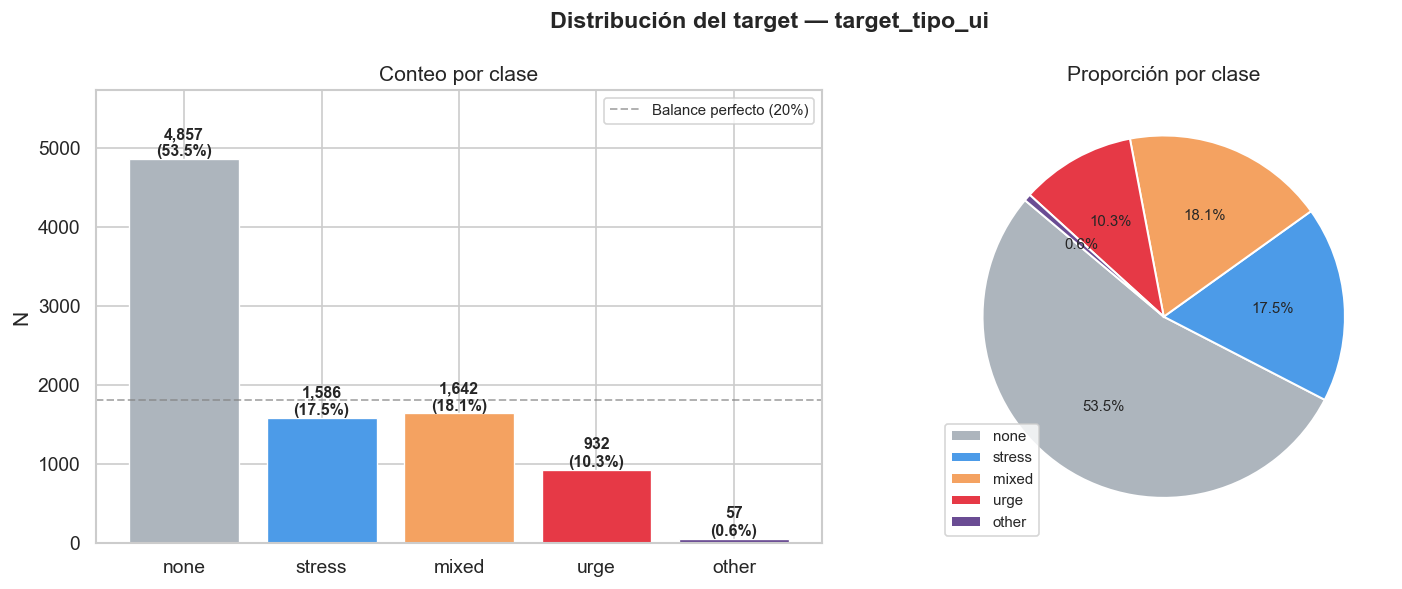

In [62]:
# Incluimos 'other' aquí porque el EDA trabaja con el dataset original
all_classes = ['none', 'stress', 'mixed', 'urge', 'other']
all_palette = {'none':'#ADB5BD','stress':'#4C9BE8','mixed':'#F4A261','urge':'#E63946','other':'#6A4C93'}

counts_all = df['target_tipo_ui'].value_counts()[all_classes]
pcts_all   = counts_all / counts_all.sum() * 100
colors_all = [all_palette[c] for c in all_classes]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribución del target — target_tipo_ui', fontsize=14, fontweight='bold')

# Barras
axes[0].bar(all_classes, counts_all.values, color=colors_all, edgecolor='white', linewidth=0.8)
for i, (v, p) in enumerate(zip(counts_all.values, pcts_all.values)):
    axes[0].text(i, v + 40, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=9.5, fontweight='bold')
axes[0].set_ylabel('N'); axes[0].set_title('Conteo por clase')
axes[0].set_ylim(0, counts_all.max() * 1.18)
axes[0].axhline(len(df) / 5, color='gray', ls='--', lw=1.2, alpha=0.6, label='Balance perfecto (20%)')
axes[0].legend(fontsize=9)

# Pie
wedges, _, autotexts = axes[1].pie(
    counts_all.values, labels=None, colors=colors_all,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
for at in autotexts: at.set_fontsize(9)
axes[1].legend(wedges, all_classes, loc='lower left', fontsize=9)
axes[1].set_title('Proporción por clase')

plt.tight_layout()
plt.savefig(assets / '01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 4 — Variables demográficas

### 4.1 Estadísticos descriptivos por clase

Antes de graficar, calculamos las métricas de resumen para las variables continuas (edad, IMC) y el nivel de pobreza familiar, separando por clase. Esto nos da una visión cuantitativa rápida de las diferencias entre grupos.

In [63]:
desc_vars = ['edad_anios', 'imc', 'nivel_pobreza_familiar']

rows = []
for cls in all_classes:
    sub = df[df['target_tipo_ui'] == cls]
    row = {'clase': cls, 'n': len(sub)}
    for v in desc_vars:
        s = sub[v].dropna()
        row[f'{v}_med']  = round(s.median(), 1)
        row[f'{v}_mean'] = round(s.mean(), 1)
        row[f'{v}_sd']   = round(s.std(), 1)
    rows.append(row)

desc_df = pd.DataFrame(rows)
print("Estadísticos por clase:")
print(desc_df.to_string(index=False))

Estadísticos por clase:
 clase    n  edad_anios_med  edad_anios_mean  edad_anios_sd  imc_med  imc_mean  imc_sd  nivel_pobreza_familiar_med  nivel_pobreza_familiar_mean  nivel_pobreza_familiar_sd
  none 4857            48.0             49.0           18.1     27.7      29.2     8.0                         3.0                          2.2                        0.9
stress 1586            51.0             50.3           15.7     29.4      30.6     7.7                         3.0                          2.3                        0.9
 mixed 1642            61.0             58.5           15.1     31.2      32.5     8.5                         3.0                          2.2                        0.9
  urge  932            62.0             57.8           16.9     30.3      31.5     8.5                         3.0                          2.3                        0.9
 other   57            51.0             51.4           19.0     30.2      31.9    10.5                         2.5       

### 4.2 Distribución de edad e IMC

Usamos KDE (curvas de densidad) para la edad y violin plots para el IMC. Las clases `urge` y `mixed` tienden a aparecer en mujeres de mayor edad, lo cual es clínicamente coherente (la vejiga hiperactiva es más frecuente con la edad).

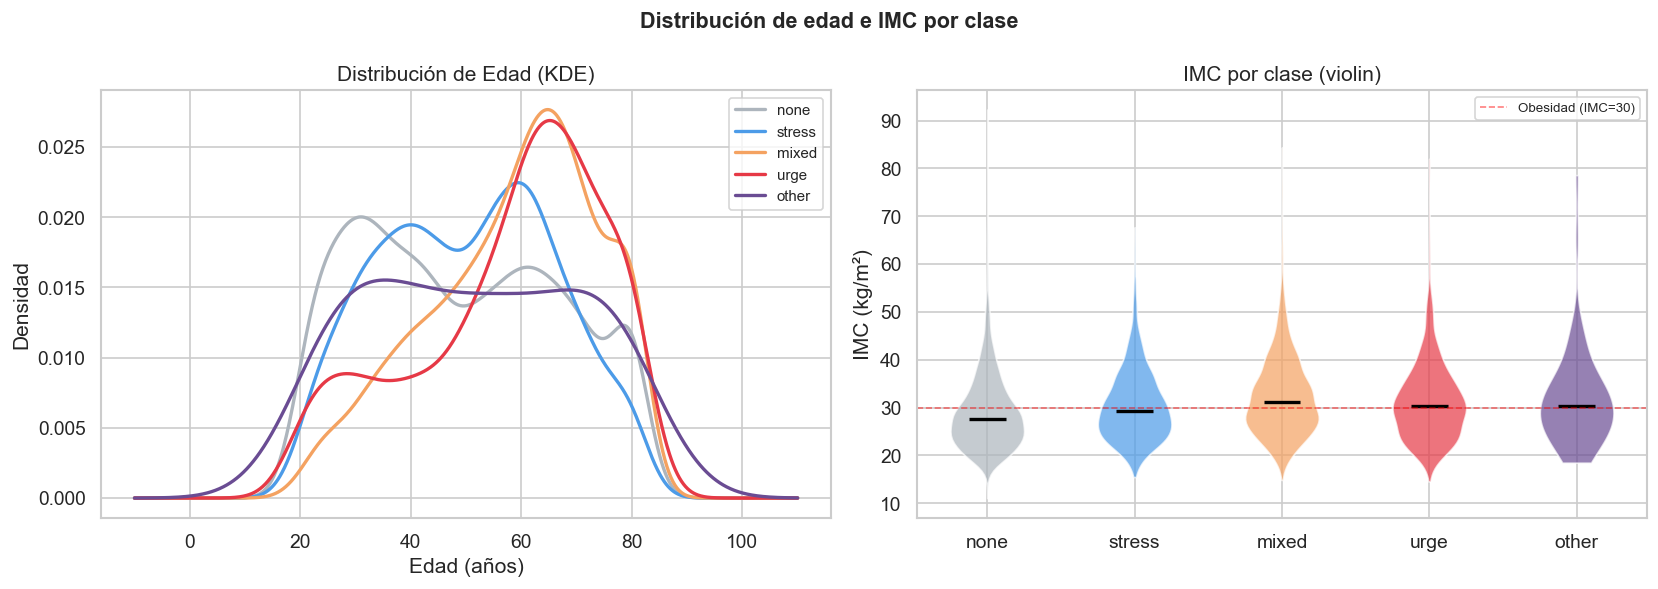

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de edad e IMC por clase', fontsize=13, fontweight='bold')

# KDE de edad
ax = axes[0]
for cls in all_classes:
    sub = df[df['target_tipo_ui'] == cls]['edad_anios'].dropna()
    sub.plot.kde(ax=ax, color=all_palette[cls], label=cls, lw=2)
ax.set_title('Distribución de Edad (KDE)')
ax.set_xlabel('Edad (años)'); ax.set_ylabel('Densidad')
ax.legend(fontsize=9)

# Violin IMC
ax = axes[1]
data_bmi = [df[df['target_tipo_ui'] == c]['imc'].dropna().values for c in all_classes]
vp = ax.violinplot(data_bmi, positions=range(len(all_classes)),
                   showmedians=True, showextrema=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors_all[i]); body.set_alpha(0.7)
vp['cmedians'].set_color('black'); vp['cmedians'].set_lw(2)
ax.set_xticks(range(len(all_classes))); ax.set_xticklabels(all_classes)
ax.set_title('IMC por clase (violin)'); ax.set_ylabel('IMC (kg/m²)')
ax.axhline(30, color='red', ls='--', lw=1, alpha=0.5, label='Obesidad (IMC=30)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(assets / '02_edad_imc.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Etnia y nivel de pobreza familiar

Exploramos la distribución de etnia y nivel socioeconómico (ratio ingreso/umbral de pobreza, INDFMMPC) por clase de UI. Estas variables pueden capturar disparidades de acceso a salud y hábitos de vida.

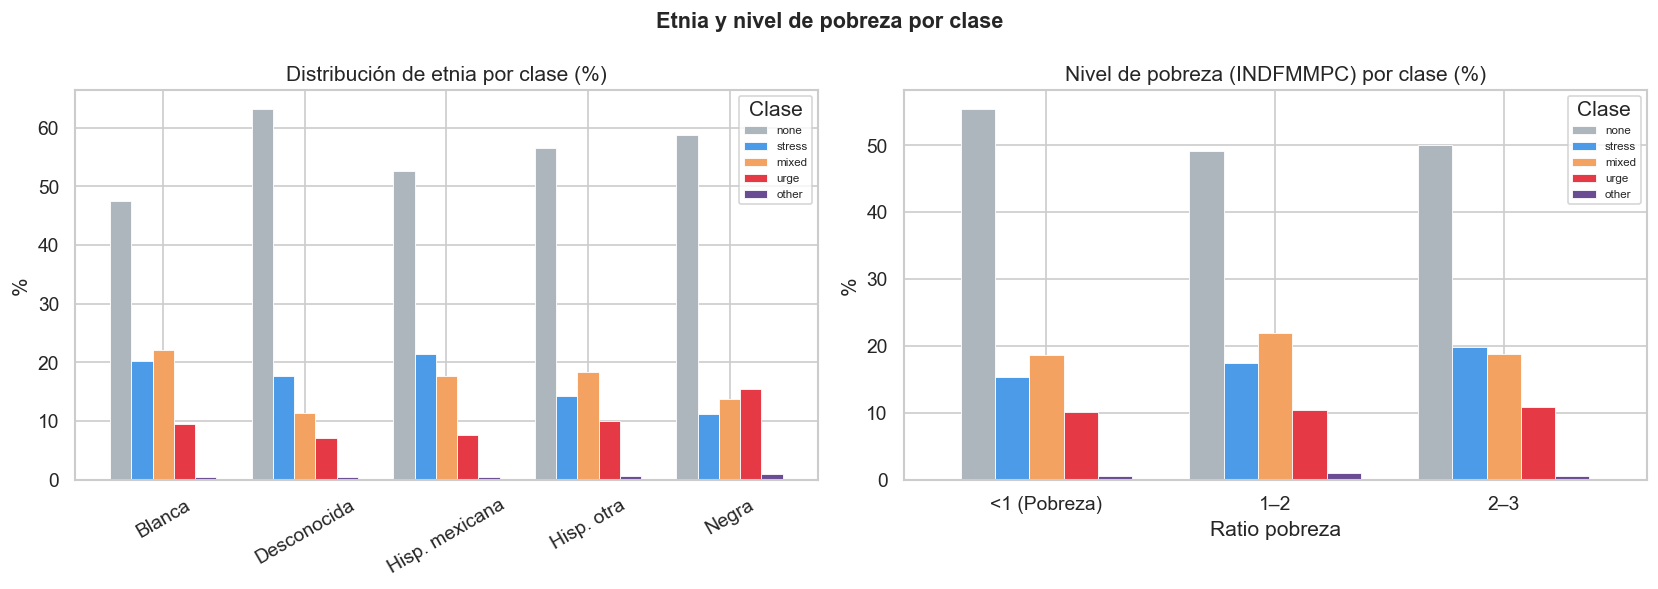

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Etnia y nivel de pobreza por clase', fontsize=13, fontweight='bold')

# Etnia
ax = axes[0]
etnia_map = {1:'Hisp. mexicana', 2:'Hisp. otra', 3:'Blanca', 4:'Negra', 6:'Asiática', 7:'Otra'}
df['etnia_lbl'] = df['etnia'].map(etnia_map).fillna('Desconocida')
etnia_ct  = df.groupby(['etnia_lbl', 'target_tipo_ui']).size().unstack(fill_value=0)
etnia_ct  = etnia_ct[[c for c in all_classes if c in etnia_ct.columns]]
etnia_pct = etnia_ct.div(etnia_ct.sum(axis=1), axis=0) * 100
etnia_pct.plot(kind='bar', ax=ax, color=colors_all[:len(etnia_pct.columns)],
               edgecolor='white', linewidth=0.5, width=0.75)
ax.set_title('Distribución de etnia por clase (%)'); ax.set_xlabel('')
ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=30)
ax.legend(title='Clase', fontsize=7)

# Nivel de pobreza
ax = axes[1]
df['npf_cat'] = pd.cut(df['nivel_pobreza_familiar'],
                        bins=[0, 1, 2, 3, 6],
                        labels=['<1 (Pobreza)', '1–2', '2–3', '>3 (Alto)'])
npf_ct  = df.groupby(['npf_cat', 'target_tipo_ui']).size().unstack(fill_value=0)
npf_ct  = npf_ct[[c for c in all_classes if c in npf_ct.columns]]
npf_pct = npf_ct.div(npf_ct.sum(axis=1), axis=0) * 100
npf_pct.plot(kind='bar', ax=ax, color=colors_all[:len(npf_pct.columns)],
             edgecolor='white', linewidth=0.5, width=0.75)
ax.set_title('Nivel de pobreza (INDFMMPC) por clase (%)'); ax.set_xlabel('Ratio pobreza')
ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=0)
ax.legend(title='Clase', fontsize=7)

plt.tight_layout()
plt.savefig(assets / '03_etnia_pobreza.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 5 — Síntomas y variables clínicas

### 5.1 Distribución de síntomas (solo casos UI+)

Analizamos los síntomas de forma individual en la submuestra de mujeres con UI positiva (excluyendo `none`). Esto nos da el perfil clínico de quienes reportaron incontinencia.

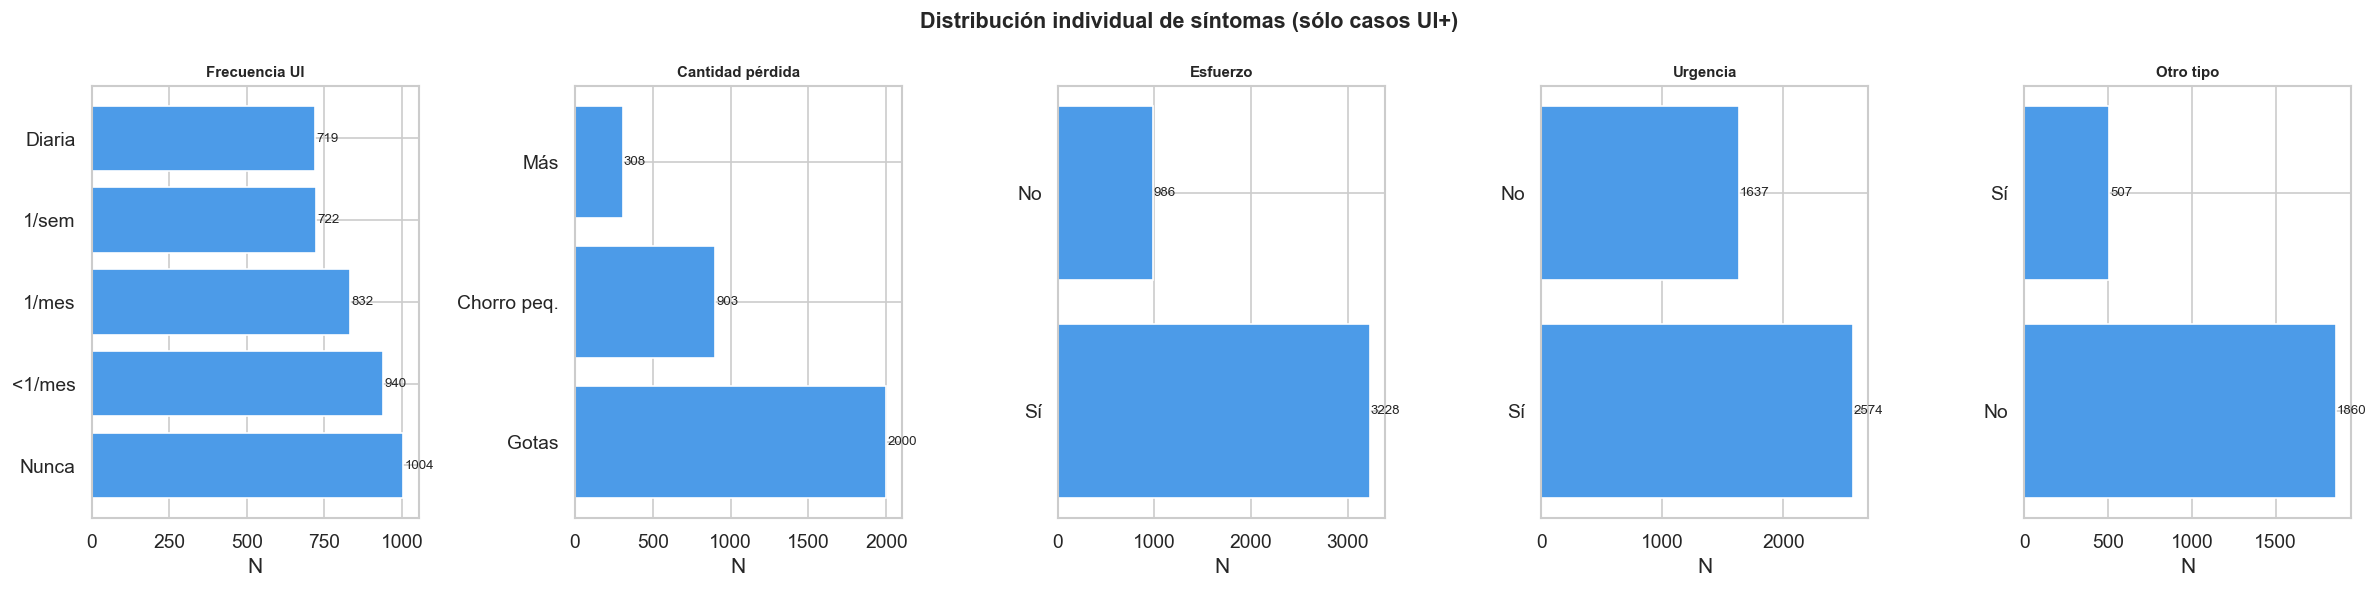

In [66]:
ui_pos = df[df['target_tipo_ui'] != 'none']

symp_info = [
    ('ui_frecuencia', 'Frecuencia UI',
     {1: 'Nunca', 2: '<1/mes', 3: '1/mes', 4: '1/sem', 5: 'Diaria', 6: 'Siempre'}),
    ('ui_cantidad', 'Cantidad pérdida',
     {1: 'Gotas', 2: 'Chorro peq.', 3: 'Más'}),
    ('ui_esfuerzo_presente', 'Esfuerzo',  {1: 'Sí', 2: 'No'}),
    ('ui_urgencia_presente', 'Urgencia',  {1: 'Sí', 2: 'No'}),
    ('ui_otro_tipo_presente','Otro tipo', {1: 'Sí', 2: 'No'}),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Distribución individual de síntomas (sólo casos UI+)', fontsize=13, fontweight='bold')

for ax, (var, title, label_map) in zip(axes, symp_info):
    sub    = ui_pos[var].dropna()
    mapped = sub.map(label_map).fillna(sub.astype(str))
    vc     = mapped.value_counts()
    ax.barh(vc.index, vc.values, color='#4C9BE8', edgecolor='white')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('N')
    for i, v in enumerate(vc.values):
        ax.text(v + 5, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig(assets / '04_symptoms_individual.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Presencia de síntomas por clase

Mostramos qué porcentaje de mujeres en cada clase reportó cada síntoma binario. La combinación de esfuerzo + urgencia en la clase `mixed` es exactamente lo que esperamos clínicamente.

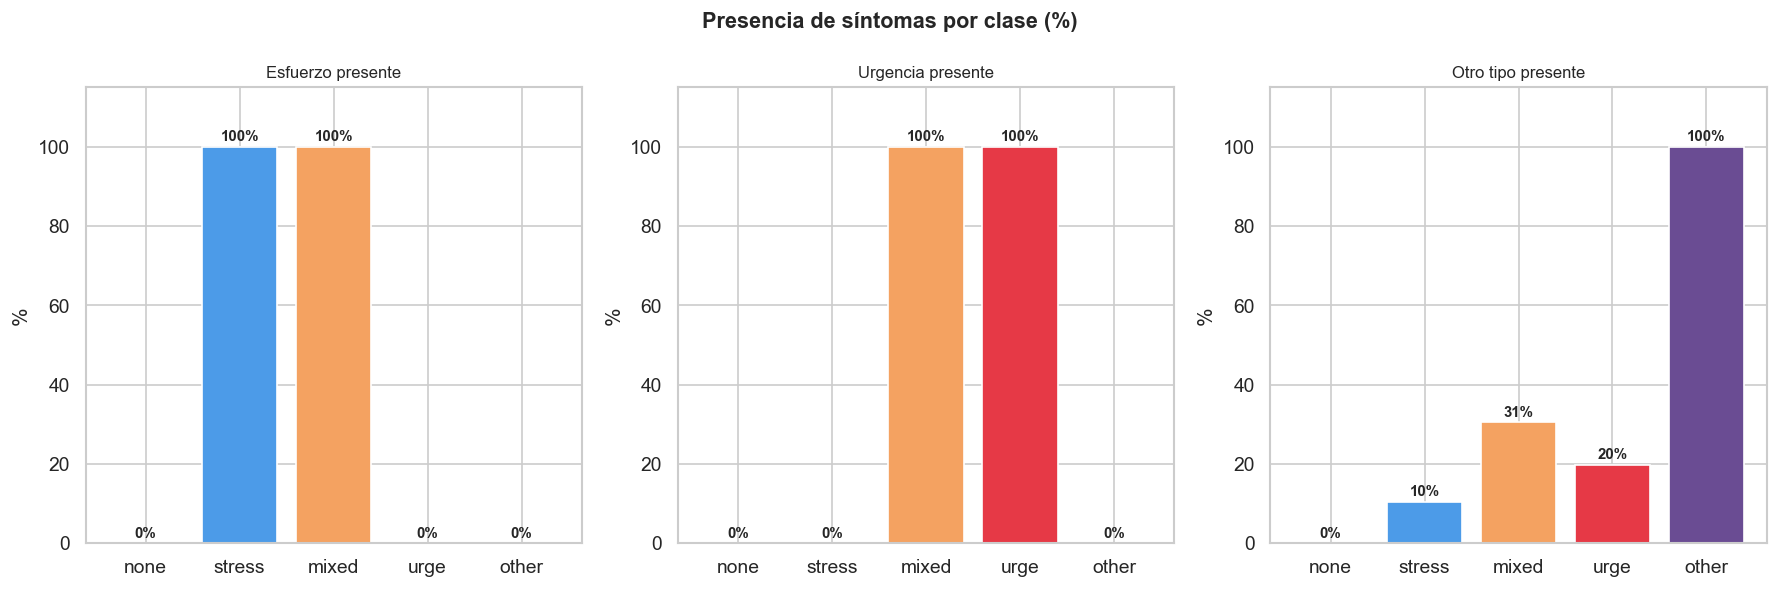

In [67]:
symptom_binary = [
    ('ui_esfuerzo_presente', 'Esfuerzo presente'),
    ('ui_urgencia_presente', 'Urgencia presente'),
    ('ui_otro_tipo_presente','Otro tipo presente'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Presencia de síntomas por clase (%)', fontsize=13, fontweight='bold')
colors_all5 = [all_palette[c] for c in all_classes]

for ax, (var, title) in zip(axes, symptom_binary):
    pcts_s = [(df[df['target_tipo_ui'] == cls][var].dropna() == 1).mean() * 100
              for cls in all_classes]
    bars = ax.bar(all_classes, pcts_s, color=colors_all5, edgecolor='white')
    ax.set_title(title, fontsize=10); ax.set_ylabel('%'); ax.set_ylim(0, 115)
    for b, p in zip(bars, pcts_s):
        ax.text(b.get_x() + b.get_width()/2, p + 1.5, f'{p:.0f}%',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(assets / '05_symptoms_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Cramér's V — Asociación de variables con el target

**Cramér's V** mide la fuerza de asociación entre dos variables categóricas (0 = independientes, 1 = asociación perfecta). Lo usamos aquí para rankear qué variables están más relacionadas con el tipo de UI.

> ⚠️ Nota: `ui_esfuerzo_presente` y `ui_urgencia_presente` tienen V=1.0 porque son la base del algoritmo con que se construyó el target. Son variables "leaky" — en el pipeline habrá que decidir si incluirlas o no según el diseño del modelo.

In [68]:
def cramers_v(x, y):
    """Calcula Cramér's V entre dos Series categóricas."""
    ct   = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1))

cat_vars = [
    'ui_frecuencia', 'ui_cantidad', 'ui_esfuerzo_presente', 'ui_urgencia_presente',
    'ui_otro_tipo_presente', 'dx_hipertension', 'dx_diabetes', 'dx_artritis',
    'ui_molestia_percibida', 'ui_impacto_actividades', 'etnia',
    'actividad_fisica_vigorosa', 'fumadora_alguna_vez',
]

cv_results = {}
for v in cat_vars:
    valid = df[[v, 'target_tipo_ui']].dropna()
    cv_results[v] = cramers_v(valid[v], valid['target_tipo_ui'])

cv_series = pd.Series(cv_results).sort_values(ascending=False)

print(f"{'Variable':<30} {'V':>6}  Interpretación")
print("-" * 60)
for var, v in cv_series.items():
    strength = '🔴 Fuerte' if v >= 0.3 else '🟡 Moderado' if v >= 0.1 else '⚪ Débil'
    print(f"  {var:<28} {v:.3f}  {strength}")

Variable                            V  Interpretación
------------------------------------------------------------
  ui_esfuerzo_presente         1.000  🔴 Fuerte
  ui_urgencia_presente         1.000  🔴 Fuerte
  ui_otro_tipo_presente        0.471  🔴 Fuerte
  ui_frecuencia                0.340  🔴 Fuerte
  ui_impacto_actividades       0.209  🟡 Moderado
  dx_artritis                  0.195  🟡 Moderado
  ui_molestia_percibida        0.177  🟡 Moderado
  ui_cantidad                  0.167  🟡 Moderado
  dx_hipertension              0.156  🟡 Moderado
  fumadora_alguna_vez          0.105  🟡 Moderado
  actividad_fisica_vigorosa    0.101  🟡 Moderado
  etnia                        0.090  ⚪ Débil
  dx_diabetes                  0.074  ⚪ Débil


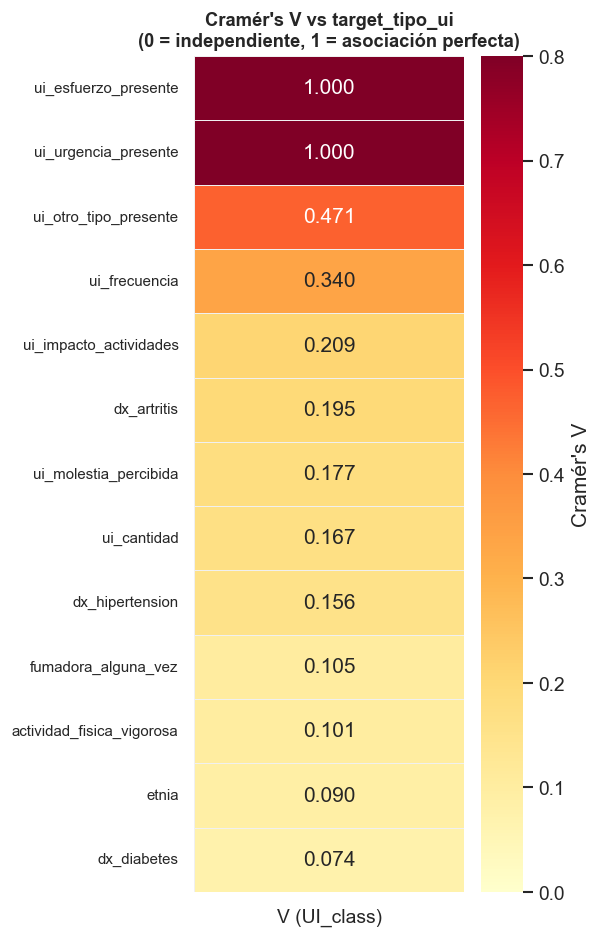

In [69]:
# Heatmap de Cramér's V
cv_df = pd.DataFrame({'V (UI_class)': cv_series})

fig, ax = plt.subplots(figsize=(5, 8))
sns.heatmap(cv_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            vmin=0, vmax=0.8, linewidths=0.5, linecolor='#f0f0f0',
            cbar_kws={'label': "Cramér's V"})
ax.set_title("Cramér's V vs target_tipo_ui\n(0 = independiente, 1 = asociación perfecta)",
             fontsize=11, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(assets / '06_cramers_v.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Variables clínicas: diabetes e hipertensión

Las mujeres con UI tienden a tener mayor prevalencia de comorbilidades metabólicas. La artritis (V=0.19) tiene mayor asociación con el tipo de UI que la diabetes (V=0.07), lo cual es un hallazgo interesante.

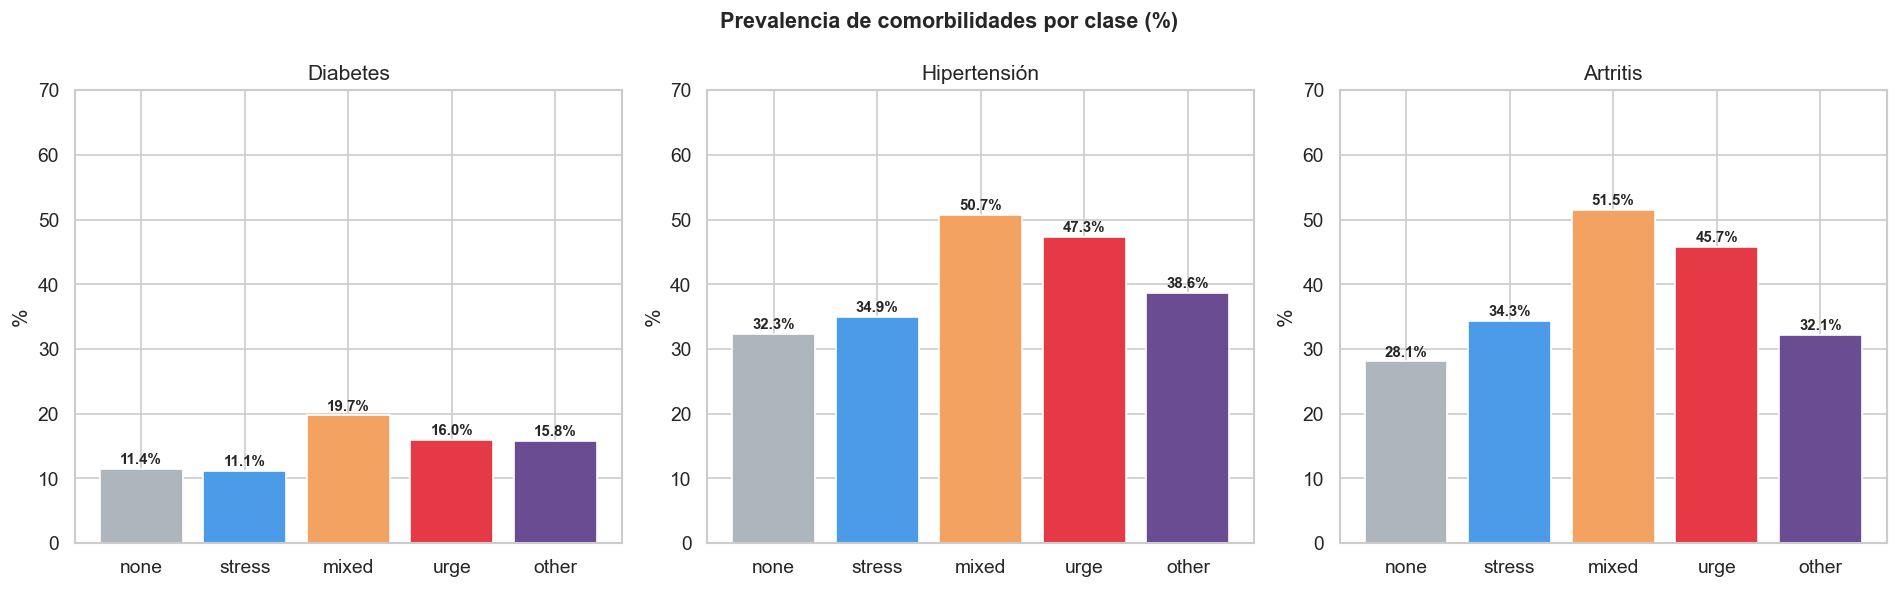

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Prevalencia de comorbilidades por clase (%)', fontsize=13, fontweight='bold')

for ax, (var, title) in zip(axes, [
    ('dx_diabetes',    'Diabetes'),
    ('dx_hipertension','Hipertensión'),
    ('dx_artritis',    'Artritis'),
]):
    pcts_c = [(df[df['target_tipo_ui'] == cls][var].dropna() == 1).mean() * 100
              for cls in all_classes]
    bars = ax.bar(all_classes, pcts_c, color=colors_all5, edgecolor='white')
    ax.set_title(title); ax.set_ylabel('%'); ax.set_ylim(0, 70)
    for b, p in zip(bars, pcts_c):
        ax.text(b.get_x() + b.get_width()/2, p + 0.8,
                f'{p:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(assets / '07_clinical_vars.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Impacto subjetivo de la UI

Analizamos cómo la molestia percibida y el impacto en actividades diarias varían entre los tipos de UI. Esto nos dice algo sobre la severidad real que experimenta cada subgrupo.

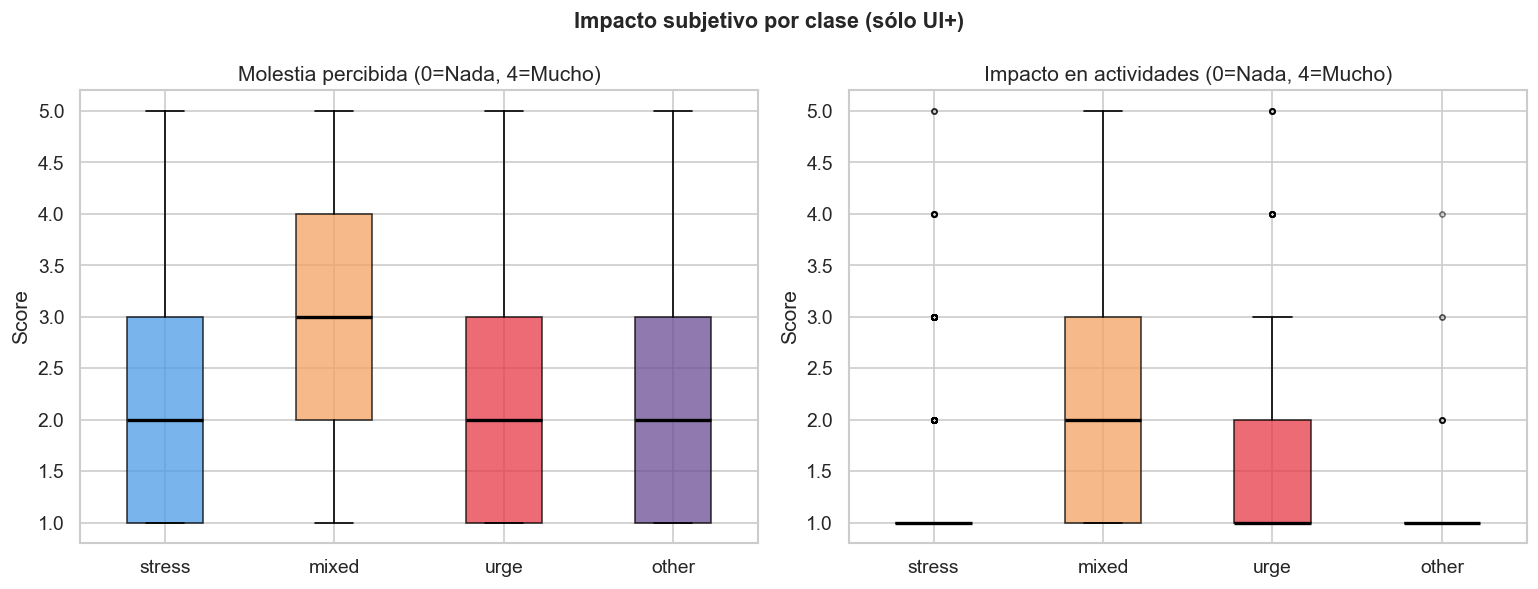

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Impacto subjetivo por clase (sólo UI+)', fontsize=13, fontweight='bold')
ui_classes_pos = ['stress', 'mixed', 'urge', 'other']

for ax, (var, title) in zip(axes, [
    ('ui_molestia_percibida',  'Molestia percibida (0=Nada, 4=Mucho)'),
    ('ui_impacto_actividades', 'Impacto en actividades (0=Nada, 4=Mucho)'),
]):
    data_plot = [df[df['target_tipo_ui'] == c][var].dropna().values for c in ui_classes_pos]
    bp = ax.boxplot(data_plot, labels=ui_classes_pos, patch_artist=True,
                    medianprops={'color': 'black', 'lw': 2},
                    flierprops={'marker': 'o', 'ms': 3, 'alpha': 0.3})
    for patch, cls in zip(bp['boxes'], ui_classes_pos):
        patch.set_facecolor(all_palette[cls]); patch.set_alpha(0.75)
    ax.set_title(title); ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig(assets / '08_subjective_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 6 — Análisis de valores faltantes

### 6.1 Resumen cuantitativo

Clasificamos cada variable según su porcentaje de missings en tres grupos:
- **<5%**: missings mínimos, fácil de manejar
- **5–20%**: nivel moderado, requiere imputación cuidadosa  
- **>20%**: alto, requiere estrategia específica o considerar eliminar la variable

In [72]:
miss    = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)

miss_df = pd.DataFrame({'n_missing': miss, 'pct_missing': miss_pct})
miss_df = miss_df[miss_df['n_missing'] > 0].sort_values('pct_missing', ascending=False)

miss_df['categoria'] = pd.cut(miss_df['pct_missing'],
    bins=[-0.001, 5, 20, 100],
    labels=['< 5%  (OK)', '5–20% (Moderado)', '> 20% (Alto)'])

print(miss_df.to_string())
print(f"\nResumen:")
print(f"  < 5%  : {(miss_df['categoria']=='< 5%  (OK)').sum()} variables")
print(f"  5–20% : {(miss_df['categoria']=='5–20% (Moderado)').sum()} variables")
print(f"  > 20% : {(miss_df['categoria']=='> 20% (Alto)').sum()} variables")

                           n_missing  pct_missing         categoria
ui_urgencia_frecuencia          7725        85.13      > 20% (Alto)
medicacion_hta_cicloL           7477        82.40      > 20% (Alto)
medicacion_hta_cicloP           7380        81.33      > 20% (Alto)
ui_esfuerzo_frecuencia          7340        80.89      > 20% (Alto)
ui_molestia_percibida           6706        73.90      > 20% (Alto)
ui_cantidad                     5525        60.89      > 20% (Alto)
ui_otro_tipo_presente           5026        55.39      > 20% (Alto)
ui_impacto_actividades          4863        53.59      > 20% (Alto)
peso_encuesta                   4753        52.38      > 20% (Alto)
actividad_fisica_vigorosa       4321        47.62      > 20% (Alto)
ui_urgencia_presente            2198        24.22      > 20% (Alto)
ui_esfuerzo_presente            2192        24.16      > 20% (Alto)
ui_frecuencia                   2187        24.10      > 20% (Alto)
imc                             1454        16.0

### 6.2 Heatmap de missings

El heatmap muestra en rojo dónde faltan datos en una muestra de 500 observaciones. Permite detectar si los missings aparecen en patrones (e.g., siempre en las mismas filas) o de forma dispersa.

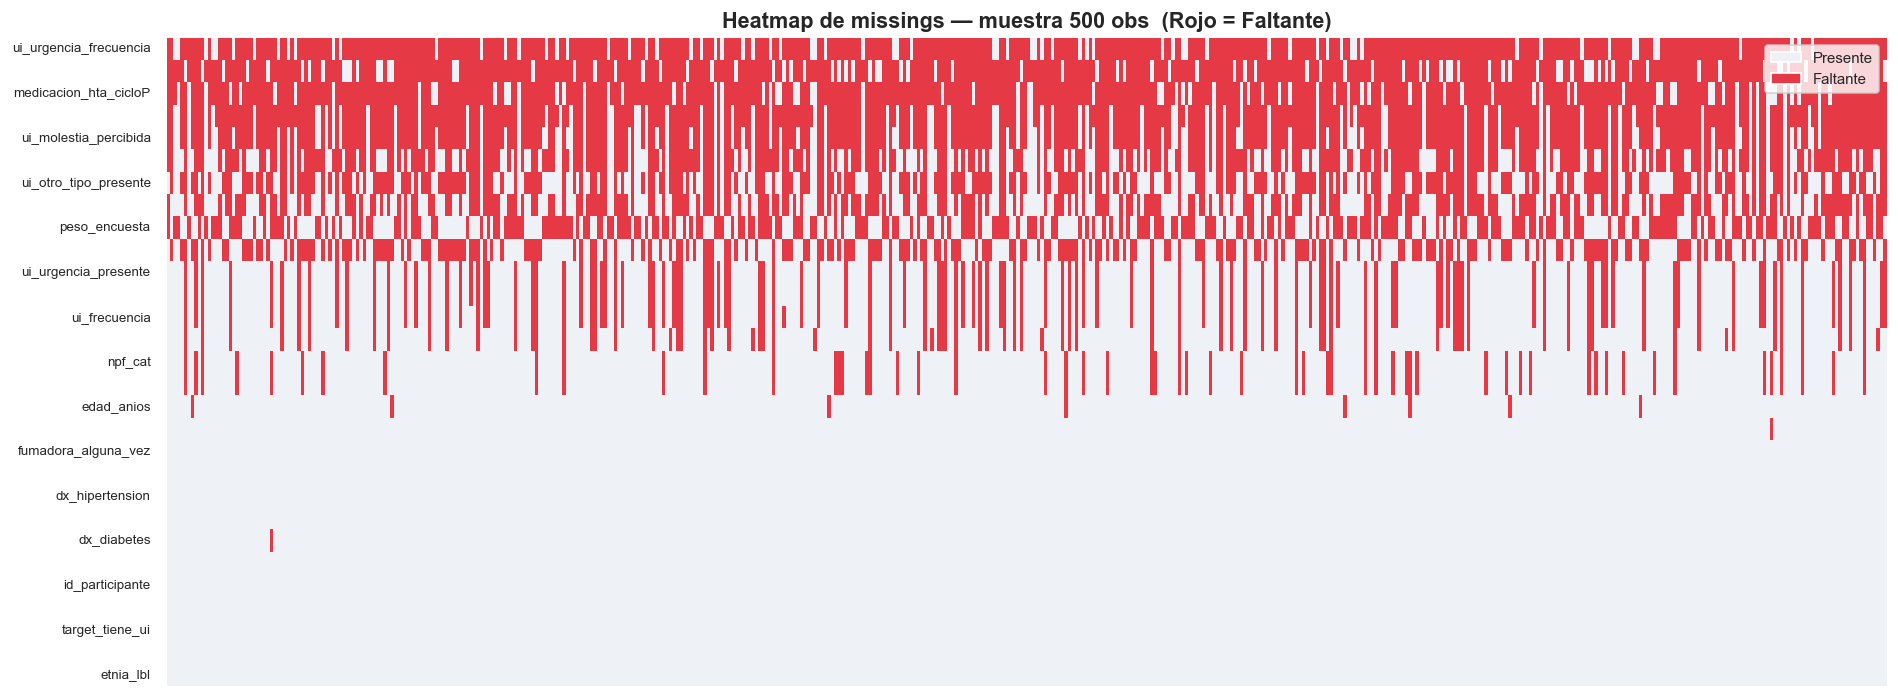

In [73]:
# Ordenamos columnas por % de missing para que sea más fácil leer el patrón
cols_sorted = miss_pct.sort_values(ascending=False).index.tolist()
df_sample   = df[cols_sorted].sample(min(500, len(df)), random_state=42)
miss_bin    = df_sample.isnull().astype(int)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(miss_bin.T, cmap=['#EEF2F7', '#E63946'], ax=ax,
            cbar=False, xticklabels=False, linewidths=0, rasterized=True)
ax.set_title('Heatmap de missings — muestra 500 obs  (Rojo = Faltante)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

legend_elem = [mpatches.Patch(facecolor='#EEF2F7', label='Presente'),
               mpatches.Patch(facecolor='#E63946', label='Faltante')]
ax.legend(handles=legend_elem, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(assets / '09_missing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Barras de porcentaje de missings

Visualización más directa del % de missings por variable, coloreada por categoría. Las variables con >80% de missings son candidatas a eliminación directa.

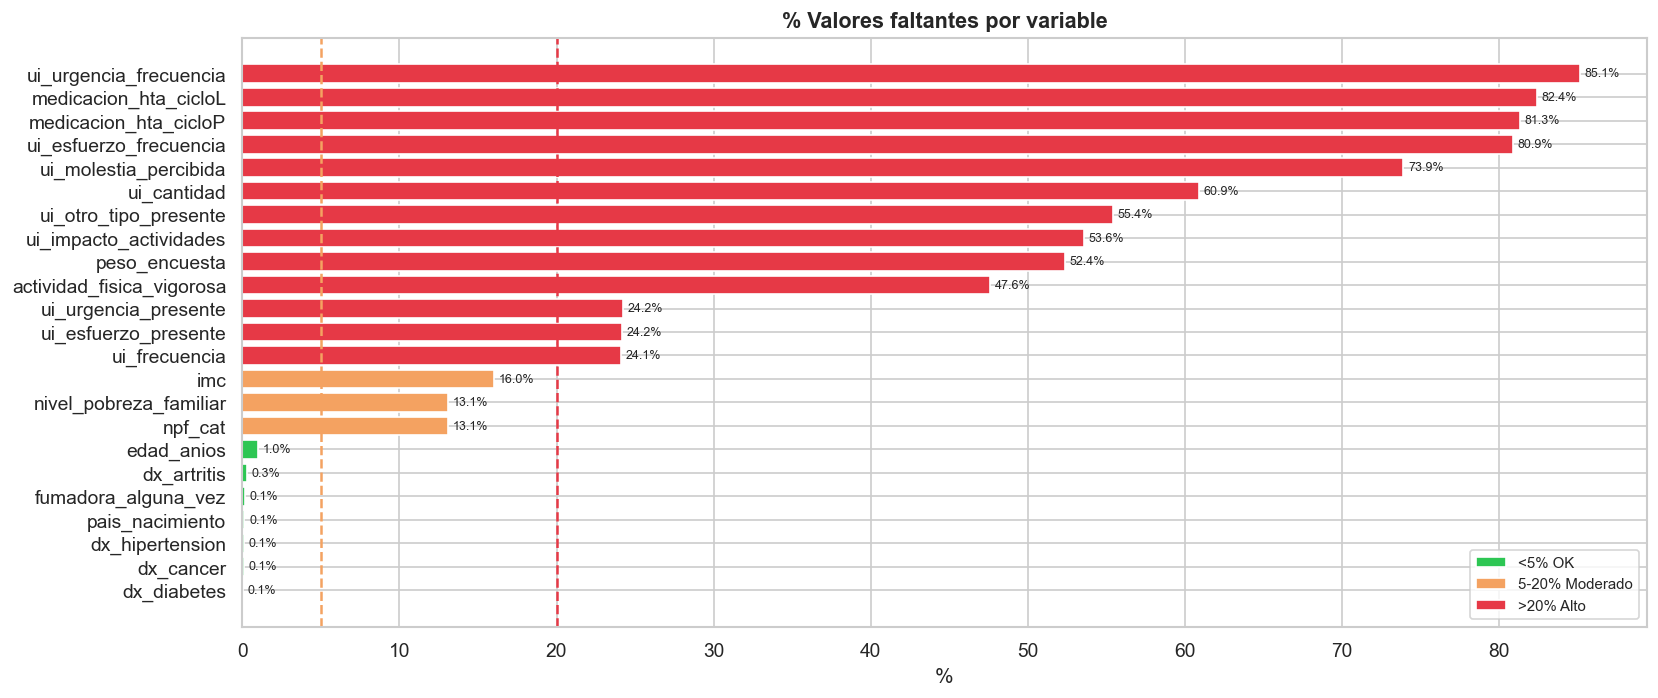

In [74]:
miss_sorted = miss_pct.sort_values(ascending=True)
miss_sorted = miss_sorted[miss_sorted > 0]

color_map = ['#2DC653' if v < 5 else '#F4A261' if v < 20 else '#E63946'
             for v in miss_sorted.values]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(miss_sorted.index, miss_sorted.values, color=color_map, edgecolor='white')
ax.axvline(5,  color='#F4A261', ls='--', lw=1.5, label='5%')
ax.axvline(20, color='#E63946', ls='--', lw=1.5, label='20%')
ax.set_title('% Valores faltantes por variable', fontsize=13, fontweight='bold')
ax.set_xlabel('%')

for bar, v in zip(bars, miss_sorted.values):
    if v > 0:
        ax.text(v + 0.3, bar.get_y() + bar.get_height()/2,
                f'{v:.1f}%', va='center', fontsize=7.5)

legend_elem = [mpatches.Patch(facecolor='#2DC653', label='<5% OK'),
               mpatches.Patch(facecolor='#F4A261', label='5-20% Moderado'),
               mpatches.Patch(facecolor='#E63946', label='>20% Alto')]
ax.legend(handles=legend_elem, fontsize=9)

plt.tight_layout()
plt.savefig(assets / '10_missing_pct_bars.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Patrón de missings por clase (test MAR)

Si el % de missings es muy diferente entre clases, los datos **no son MCAR** (no faltan al azar puro) — hay un patrón sistemático. Este análisis visual nos ayuda a diagnosticar si estamos ante MAR o MNAR.

**Qué buscar:** Las variables UI con ~24% missing deberían tener cerca del 0% en clase `none` (porque esas preguntas solo se hacen a mujeres con UI+). Eso confirma **MAR estructural**.

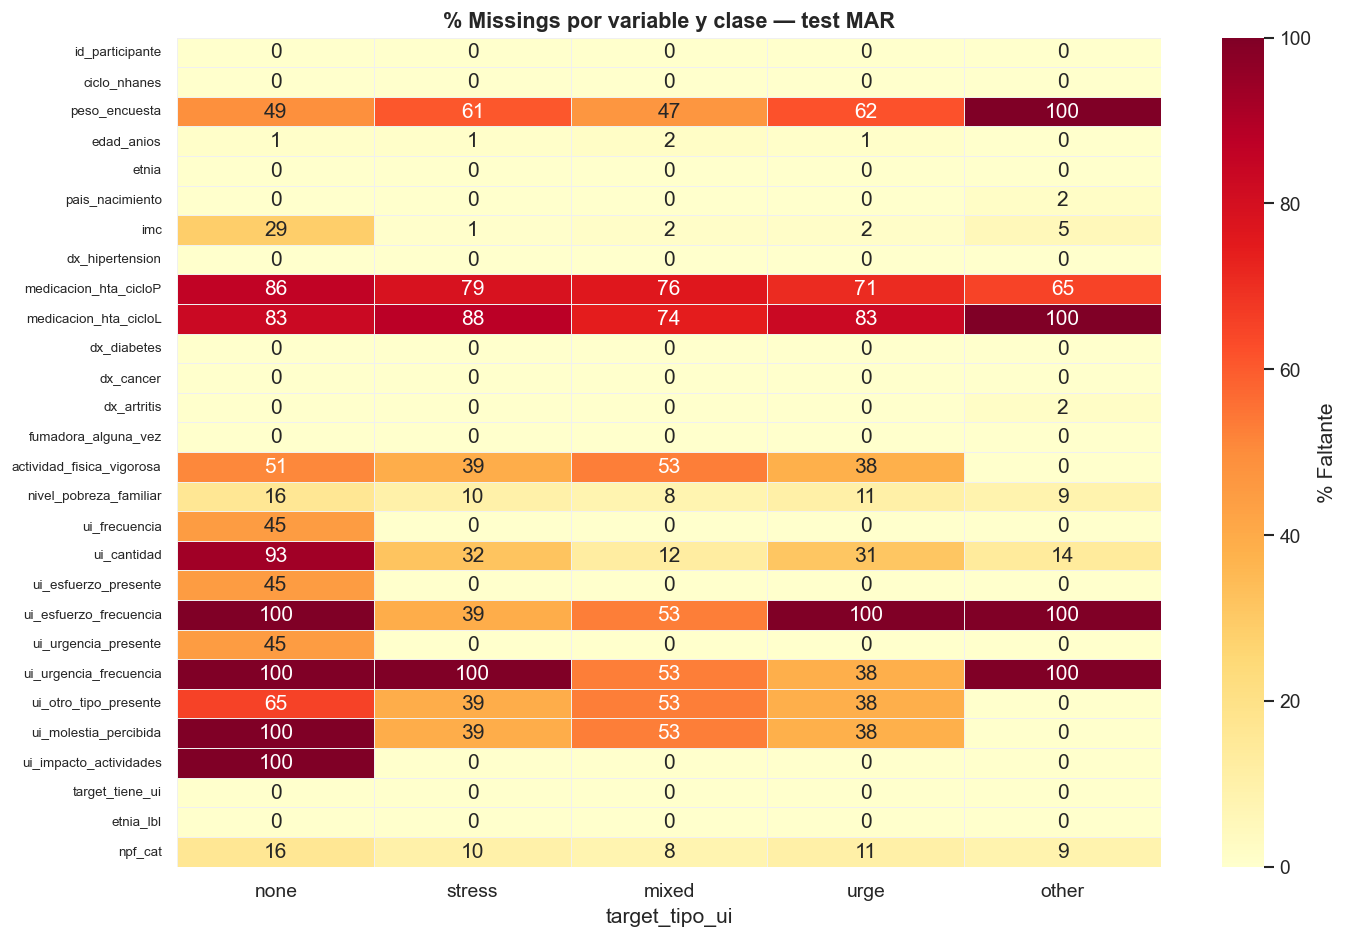


Conclusiones:
  - ui_* (~24% missing): MAR estructural. Los missings están concentrados en clase 'none'.
  - actividad_fisica_vigorosa (47.6%): MAR. Más missings en personas mayores.
  - nivel_pobreza_familiar (9.97%): MNAR. Non-response relacionado con ingreso real.
  - imc (16%): MAR. Más missings en participantes jóvenes.
  - medicacion_hta_* (>80%): MAR estructural. Solo en subconjunto clínico → ELIMINAR.


In [75]:
miss_by_class = (df.groupby('target_tipo_ui')
                    .apply(lambda g: g.isnull().mean() * 100)
                    .T)
miss_by_class = miss_by_class[all_classes]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(miss_by_class, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            vmin=0, vmax=100, linewidths=0.4, linecolor='#f0f0f0',
            cbar_kws={'label': '% Faltante'})
ax.set_title('% Missings por variable y clase — test MAR', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(assets / '11_missing_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nConclusiones:")
print("  - ui_* (~24% missing): MAR estructural. Los missings están concentrados en clase 'none'.")
print("  - actividad_fisica_vigorosa (47.6%): MAR. Más missings en personas mayores.")
print("  - nivel_pobreza_familiar (9.97%): MNAR. Non-response relacionado con ingreso real.")
print("  - imc (16%): MAR. Más missings en participantes jóvenes.")
print("  - medicacion_hta_* (>80%): MAR estructural. Solo en subconjunto clínico → ELIMINAR.")

---
## Sección 7 — Conclusiones del EDA

### Resumen ejecutivo

#### ✅ Dataset validado
- **9.074 filas × 27 columnas** confirmadas
- **26 combinaciones** de códigos CDC (7, 9, 77, 99) identificadas y corregidas

---

#### 📊 Target y desbalanceo
| Clase | N | % | Acción |
|---|---|---|---|
| none | 4.857 | 53.5% | Clase de referencia |
| mixed | 1.642 | 18.1% | OK |
| stress | 1.586 | 17.5% | OK |
| urge | 932 + 57 | 10.9% | Fusionar `other` + aplicar SMOTE |
| other | 57 | 0.6% | **→ Fusionar con `urge`** |

Ratio `none:urge` = **5.2x** → requiere estrategia de balanceo en el pipeline.

---

#### 👥 Demografía
- Clases `urge` y `mixed` son más frecuentes en mujeres **mayores** (mediana ~62 años vs 48 en `none`)
- Mayor **IMC** en clases UI+ que en `none` — relación clínicamente esperada
- Diferencias de etnia y nivel socioeconómico son leves (V < 0.10)

---

#### 🔬 Predictores más potentes (Cramér's V)
| Variable | V | Nota |
|---|---|---|
| ui_esfuerzo_presente | 1.00 | ⚠️ Leaky — define el target directamente |
| ui_urgencia_presente | 1.00 | ⚠️ Leaky — define el target directamente |
| ui_otro_tipo_presente | 0.47 | Fuerte, incluir |
| ui_frecuencia | 0.34 | Moderado-fuerte |
| ui_impacto_actividades | 0.21 | Moderado |
| dx_artritis | 0.19 | Interesante — mayor que diabetes |

---

#### ❓ Missings — Estrategia definida
| Grupo | Variables | Decisión |
|---|---|---|
| >80% missing | `medicacion_hta_*`, `ui_*_frecuencia` | **ELIMINAR** |
| ~50% missing | `peso_encuesta` | **ELIMINAR** (peso muestral, no predictivo) |
| MAR estructural (UI cond.) | `ui_cantidad`, `ui_molestia_percibida`, etc. | **KNN Imputer** |
| MAR/MNAR | `nivel_pobreza_familiar`, `imc` | **KNN Imputer** |
| <5% | Diagnósticos clínicos | **Moda** |

---

> ✅ El EDA está completo. Las conclusiones guían directamente el ETL de la siguiente sección.


---
## Sección 8 — ETL: Limpieza y transformación

### 8.1 Librerías adicionales para el ETL

El ETL requiere herramientas de scikit-learn para imputación y encoding. Las importamos aquí para mantener el flujo separado del EDA.

In [76]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder

print("✓ Librerías ETL cargadas")

✓ Librerías ETL cargadas


### 8.2 Punto de partida limpio

Arrancamos el ETL desde el dataset con los códigos CDC ya reemplazados por NaN (procesado en la Sección 2). Hacemos una copia limpia para no contaminar el análisis del EDA.

In [77]:
# df ya tiene los CDC codes reemplazados por NaN (ver Sección 2.3)
df_etl = df.copy()

# Eliminamos columnas auxiliares que creamos durante el EDA
etl_drop_aux = ['etnia_lbl', 'npf_cat']
for col in etl_drop_aux:
    if col in df_etl.columns:
        df_etl.drop(columns=[col], inplace=True)

print(f"Punto de partida ETL: {df_etl.shape[0]:,} filas × {df_etl.shape[1]} columnas")
print(f"Total missings: {df_etl.isnull().sum().sum():,}")

Punto de partida ETL: 9,074 filas × 27 columnas
Total missings: 70,501


### 8.3 Fusión de clase 'other' → 'urge'

Identificamos los 57 casos con categoría `other` y los reasignamos a `urge`. La justificación clínica es que la "otra" incontinencia que no es esfuerzo ni mixta comparte mecanismo con la urgencia. Esto nos deja con **4 clases limpias**.

In [78]:
# Antes de la fusión
print("Antes de la fusión:")
print(df_etl['target_tipo_ui'].value_counts().to_string())

# Identificar los casos 'other'
mask_other = df_etl['target_tipo_ui'] == 'other'
print(f"\n→ Casos 'other' a reasignar: {mask_other.sum()}")

# Reasignamos a 'urge'
df_etl.loc[mask_other, 'target_tipo_ui'] = 'urge'

print("\nDespués de la fusión:")
print(df_etl['target_tipo_ui'].value_counts().to_string())
assert df_etl['target_tipo_ui'].nunique() == 4, "✗ ERROR: no quedan exactamente 4 clases"
print("\n✓ Target con exactamente 4 clases limpias")

Antes de la fusión:
target_tipo_ui
none      4857
mixed     1642
stress    1586
urge       932
other       57

→ Casos 'other' a reasignar: 57

Después de la fusión:
target_tipo_ui
none      4857
mixed     1642
stress    1586
urge       989

✓ Target con exactamente 4 clases limpias


### 8.4 Eliminación de columnas no útiles

Eliminamos variables que no aportarán al modelo:
- **Identificadores:** no predictivos
- **Variables con >80% de missings:** demasiado vacías para imputar de forma confiable
- **Variables derivadas o redundantes:** crean fuga de datos o colinealidad
- **Peso muestral:** es para análisis de encuesta, no para modelado predictivo

In [79]:
cols_a_eliminar = {
    'id_participante':      'Identificador — no predictivo',
    'ciclo_nhanes':         'Una sola categoría — no informativo',
    'peso_encuesta':        'Peso muestral (52% missing) — no predictivo',
    'medicacion_hta_cicloP':'82% missing + alta colinealidad con dx_hipertension',
    'medicacion_hta_cicloL':'81% missing + alta colinealidad con dx_hipertension',
    'ui_esfuerzo_frecuencia':'80% missing + derivada de ui_esfuerzo_presente',
    'ui_urgencia_frecuencia':'85% missing + derivada de ui_urgencia_presente',
    'target_tiene_ui':      'Directamente derivada del target — data leakage',
}

print("Columnas eliminadas:")
for col, razon in cols_a_eliminar.items():
    if col in df_etl.columns:
        df_etl.drop(columns=[col], inplace=True)
        print(f"  ✗ {col:<30} → {razon}")

print(f"\nDataset tras eliminación: {df_etl.shape[0]:,} filas × {df_etl.shape[1]} columnas")

Columnas eliminadas:
  ✗ id_participante                → Identificador — no predictivo
  ✗ ciclo_nhanes                   → Una sola categoría — no informativo
  ✗ peso_encuesta                  → Peso muestral (52% missing) — no predictivo
  ✗ medicacion_hta_cicloP          → 82% missing + alta colinealidad con dx_hipertension
  ✗ medicacion_hta_cicloL          → 81% missing + alta colinealidad con dx_hipertension
  ✗ ui_esfuerzo_frecuencia         → 80% missing + derivada de ui_esfuerzo_presente
  ✗ ui_urgencia_frecuencia         → 85% missing + derivada de ui_urgencia_presente
  ✗ target_tiene_ui                → Directamente derivada del target — data leakage

Dataset tras eliminación: 9,074 filas × 19 columnas


### 8.5 Recodificación de variables binarias (1/2 → 0/1)

En NHANES las variables binarias suelen estar codificadas como 1=Sí y 2=No. Las recodificamos a la convención estándar de machine learning: **1=Sí / 0=No**.

In [80]:
binary_cols = [
    'dx_hipertension', 'dx_diabetes', 'dx_cancer', 'dx_artritis',
    'fumadora_alguna_vez', 'ui_esfuerzo_presente',
    'ui_urgencia_presente', 'ui_otro_tipo_presente',
]

for col in binary_cols:
    if col in df_etl.columns:
        df_etl[col] = df_etl[col].map({1: 1, 2: 0})

print("Distribución después del recode (ejemplo: dx_diabetes):")
print(df_etl['dx_diabetes'].value_counts(dropna=False))

Distribución después del recode (ejemplo: dx_diabetes):
dx_diabetes
0.0    7588
1.0    1213
NaN     273
Name: count, dtype: int64


### 8.6 Imputación — Variables con pocos missings (<5%)

Para variables con muy pocos missings usamos la estrategia más simple: la **moda** (el valor más frecuente). Es adecuada para variables categóricas/binarias cuando los missings son escasos y no tienen un patrón claro.

In [81]:
moda_vars = [
    'pais_nacimiento', 'dx_hipertension', 'dx_diabetes',
    'dx_cancer', 'dx_artritis', 'fumadora_alguna_vez',
]

print("Imputación por moda:")
for col in moda_vars:
    if col in df_etl.columns and df_etl[col].isnull().sum() > 0:
        moda_val = df_etl[col].mode()[0]
        n_miss   = df_etl[col].isnull().sum()
        df_etl[col] = df_etl[col].fillna(moda_val)
        print(f"  {col:<28} → moda={moda_val:.0f}  ({n_miss} valores imputados)")

# Edad: 92 missings por código CDC 77, imputamos con mediana
med_edad = df_etl['edad_anios'].median()
n_miss   = df_etl['edad_anios'].isnull().sum()
df_etl['edad_anios'] = df_etl['edad_anios'].fillna(med_edad)
print(f"  {'edad_anios':<28} → mediana={med_edad}  ({n_miss} valores imputados)")

print(f"\nMissings tras imputación simple: {df_etl.isnull().sum().sum():,}")

Imputación por moda:
  pais_nacimiento              → moda=1  (12 valores imputados)
  dx_hipertension              → moda=0  (10 valores imputados)
  dx_diabetes                  → moda=0  (273 valores imputados)
  dx_cancer                    → moda=0  (8 valores imputados)
  dx_artritis                  → moda=0  (27 valores imputados)
  fumadora_alguna_vez          → moda=0  (14 valores imputados)
  edad_anios                   → mediana=53.0  (92 valores imputados)

Missings tras imputación simple: 35,658


### 8.7 Imputación — Variables MAR con KNNImputer

Para las variables con patrón MAR (el missing depende de otras variables observables), usamos **KNNImputer**: busca los K vecinos más cercanos en el espacio de las demás variables y usa sus valores para imputar. Es más sofisticado que la mediana global porque respeta las correlaciones del dataset.

El parámetro `n_neighbors=5` es el estándar recomendado como punto de partida.

In [82]:
knn_vars = [
    'imc',                      # 16% — MAR, correlaciona con edad y clase
    'nivel_pobreza_familiar',   # 10% — MNAR leve, correlaciona con etnia
    'actividad_fisica_vigorosa',# 48% — MAR, más missings en mayores
    'ui_frecuencia',            # 24% — MAR estructural (condicionada a UI+)
    'ui_cantidad',              # 61% — MAR estructural
    'ui_esfuerzo_presente',     # 24% — MAR estructural
    'ui_urgencia_presente',     # 24% — MAR estructural
    'ui_otro_tipo_presente',    # 55% — MAR estructural
    'ui_molestia_percibida',    # 74% — MAR estructural
    'ui_impacto_actividades',   # 54% — MAR estructural
]

knn_vars = [c for c in knn_vars if c in df_etl.columns]

print(f"Missings antes del KNN:")
for col in knn_vars:
    print(f"  {col:<30} {df_etl[col].isnull().sum():>5} missings ({df_etl[col].isnull().mean()*100:.1f}%)")

imputer = KNNImputer(n_neighbors=5)
df_etl[knn_vars] = imputer.fit_transform(df_etl[knn_vars])

print(f"\nMissings tras KNNImputer: {df_etl[knn_vars].isnull().sum().sum()}")

Missings antes del KNN:
  imc                             1454 missings (16.0%)
  nivel_pobreza_familiar          1186 missings (13.1%)
  actividad_fisica_vigorosa       4321 missings (47.6%)
  ui_frecuencia                   2187 missings (24.1%)
  ui_cantidad                     5525 missings (60.9%)
  ui_esfuerzo_presente            2192 missings (24.2%)
  ui_urgencia_presente            2198 missings (24.2%)
  ui_otro_tipo_presente           5026 missings (55.4%)
  ui_molestia_percibida           6706 missings (73.9%)
  ui_impacto_actividades          4863 missings (53.6%)

Missings tras KNNImputer: 0


### 8.8 Redondeo y ajuste de variables ordinales/binarias post-KNN

El KNNImputer trabaja con promedios ponderados, así que puede producir valores continuos para variables que deben ser enteras (e.g., 0.6 en vez de 1 para una variable binaria). Las redondeamos y limitamos al rango válido.

In [83]:
# Redondear y clampear al rango original de cada variable
round_specs = {
    'actividad_fisica_vigorosa': (0, 1),
    'ui_frecuencia':             (1, 6),
    'ui_cantidad':               (1, 3),
    'ui_esfuerzo_presente':      (0, 1),
    'ui_urgencia_presente':      (0, 1),
    'ui_otro_tipo_presente':     (0, 1),
    'ui_molestia_percibida':     (0, 4),
    'ui_impacto_actividades':    (0, 4),
}

for col, (vmin, vmax) in round_specs.items():
    if col in df_etl.columns:
        df_etl[col] = df_etl[col].round().clip(vmin, vmax).astype(int)

print("✓ Variables ordinales/binarias redondeadas y ajustadas al rango válido")
print(f"  Missings totales en el dataset: {df_etl.isnull().sum().sum()}")

✓ Variables ordinales/binarias redondeadas y ajustadas al rango válido
  Missings totales en el dataset: 0


### 8.9 Encoding de variables categóricas

**Etnia** y **país de nacimiento** son variables nominales (sin orden) → usamos **One-Hot Encoding** (OHE). Esto crea una columna binaria por cada categoría.

**Nivel de pobreza familiar** (`nivel_pobreza_familiar`) es un ratio numérico continuo → lo dejamos tal cual, no necesita encoding.

> Nota: el OHE de etnia crea 6 columnas pero omitimos una (la de referencia) para evitar multicolinealidad — esto lo hará automáticamente `pd.get_dummies` con `drop_first=True`.

In [84]:
# Etnia → One-Hot Encoding
etnia_map = {1:'hisp_mex', 2:'hisp_otra', 3:'blanca', 4:'negra', 6:'asiatica', 7:'otra'}
df_etl['etnia_lbl'] = df_etl['etnia'].map(etnia_map).fillna('otra')
etnia_dummies = pd.get_dummies(df_etl['etnia_lbl'], prefix='etnia', drop_first=False, dtype=int)
df_etl = pd.concat([df_etl.drop(columns=['etnia', 'etnia_lbl']), etnia_dummies], axis=1)
print(f"Columnas de etnia creadas: {[c for c in df_etl.columns if c.startswith('etnia')]}")

# País de nacimiento → One-Hot Encoding
pais_map = {1: 'usa', 2: 'mexico', 3: 'otro'}
df_etl['pais_lbl'] = df_etl['pais_nacimiento'].map(pais_map).fillna('otro')
pais_dummies = pd.get_dummies(df_etl['pais_lbl'], prefix='pais', drop_first=False, dtype=int)
df_etl = pd.concat([df_etl.drop(columns=['pais_nacimiento', 'pais_lbl']), pais_dummies], axis=1)
print(f"Columnas de país creadas:  {[c for c in df_etl.columns if c.startswith('pais')]}")

Columnas de etnia creadas: ['etnia_blanca', 'etnia_hisp_mex', 'etnia_hisp_otra', 'etnia_negra', 'etnia_otra']
Columnas de país creadas:  ['pais_mexico', 'pais_usa']


### 8.10 Verificación final del dataset limpio

Antes de guardar, verificamos que el dataset cumple todos los criterios de calidad:
- ✅ 0 valores nulos
- ✅ 4 clases en el target
- ✅ Todos los tipos de datos correctos
- ✅ Rangos válidos en variables ordinales

In [85]:
print("=" * 55)
print("VERIFICACIÓN FINAL DEL DATASET ETL")
print("=" * 55)

# 1. Missings
total_miss = df_etl.isnull().sum().sum()
print(f"\n1. Valores nulos totales: {total_miss}  {'✓' if total_miss == 0 else '✗ HAY NULOS'}")

# 2. Clases
clases = df_etl['target_tipo_ui'].unique()
print(f"2. Clases del target: {sorted(clases)}  {'✓' if len(clases) == 4 else '✗'}")

# 3. Distribución final del target
print("\n3. Distribución final del target:")
for cls, n in df_etl['target_tipo_ui'].value_counts()[CLASS_ORDER].items():
    pct = n / len(df_etl) * 100
    print(f"   {cls:<10} {n:>6,}  ({pct:.1f}%)")

# 4. Shape
print(f"\n4. Shape final: {df_etl.shape[0]:,} filas × {df_etl.shape[1]} columnas")

# 5. Columnas finales
print(f"\n5. Columnas finales:")
print(df_etl.columns.tolist())

VERIFICACIÓN FINAL DEL DATASET ETL

1. Valores nulos totales: 0  ✓
2. Clases del target: ['mixed', 'none', 'stress', 'urge']  ✓

3. Distribución final del target:
   none        4,857  (53.5%)
   stress      1,586  (17.5%)
   mixed       1,642  (18.1%)
   urge          989  (10.9%)

4. Shape final: 9,074 filas × 24 columnas

5. Columnas finales:
['edad_anios', 'imc', 'dx_hipertension', 'dx_diabetes', 'dx_cancer', 'dx_artritis', 'fumadora_alguna_vez', 'actividad_fisica_vigorosa', 'nivel_pobreza_familiar', 'ui_frecuencia', 'ui_cantidad', 'ui_esfuerzo_presente', 'ui_urgencia_presente', 'ui_otro_tipo_presente', 'ui_molestia_percibida', 'ui_impacto_actividades', 'target_tipo_ui', 'etnia_blanca', 'etnia_hisp_mex', 'etnia_hisp_otra', 'etnia_negra', 'etnia_otra', 'pais_mexico', 'pais_usa']


In [86]:
# Tipos de datos finales
print("Tipos de datos finales:")
print(df_etl.dtypes.to_string())

Tipos de datos finales:
edad_anios                   float64
imc                          float64
dx_hipertension              float64
dx_diabetes                  float64
dx_cancer                    float64
dx_artritis                  float64
fumadora_alguna_vez          float64
actividad_fisica_vigorosa      int64
nivel_pobreza_familiar       float64
ui_frecuencia                  int64
ui_cantidad                    int64
ui_esfuerzo_presente           int64
ui_urgencia_presente           int64
ui_otro_tipo_presente          int64
ui_molestia_percibida          int64
ui_impacto_actividades         int64
target_tipo_ui                   str
etnia_blanca                   int64
etnia_hisp_mex                 int64
etnia_hisp_otra                int64
etnia_negra                    int64
etnia_otra                     int64
pais_mexico                    int64
pais_usa                       int64


In [87]:
# Vista previa del dataset limpio
df_etl.head(5)

,edad_anios,imc,dx_hipertension,dx_diabetes,dx_cancer,dx_artritis,fumadora_alguna_vez,actividad_fisica_vigorosa,nivel_pobreza_familiar,ui_frecuencia,...,ui_molestia_percibida,ui_impacto_actividades,target_tipo_ui,etnia_blanca,etnia_hisp_mex,etnia_hisp_otra,etnia_negra,etnia_otra,pais_mexico,pais_usa
0,29.0,37.80,0.0,0.0,0.0,0.0,0.0,1,3.0,1,...,1,1,none,0,0,0,0,1,1,0
1,21.0,30.04,0.0,0.0,0.0,0.0,0.0,1,3.0,2,...,1,1,none,0,0,1,0,0,1,0
2,44.0,39.10,0.0,0.0,0.0,0.0,0.0,1,2.4,4,...,2,2,stress,0,1,0,0,0,1,0
3,33.0,28.90,0.0,0.0,0.0,0.0,0.0,1,1.0,2,...,1,1,none,0,0,0,0,1,1,0
4,68.0,28.10,1.0,1.0,0.0,1.0,0.0,1,3.0,3,...,2,1,urge,0,0,0,1,0,0,1


### 8.11 Guardado del dataset limpio

Guardamos el dataset procesado en `data/processed/nhanes_clean.csv`. Este archivo es el input directo del pipeline de modelado.

In [88]:
output_path = data_processed / 'nhanes_clean.csv'
df_etl.to_csv(output_path, index=False)

import os
file_size = os.path.getsize(output_path) / 1024
print(f"✓ Dataset guardado en: {output_path}")
print(f"  Tamaño: {file_size:.1f} KB")
print(f"  Shape:  {df_etl.shape[0]:,} filas × {df_etl.shape[1]} columnas")
print(f"  Clases: {df_etl['target_tipo_ui'].value_counts().to_dict()}")

✓ Dataset guardado en: C:\Users\Coder\Documents\Proyectos-Modulo2\Proyecto7_Equipo3_Multiclase\data\processed\nhanes_clean.csv
  Tamaño: 642.6 KB
  Shape:  9,074 filas × 24 columnas
  Clases: {'none': 4857, 'mixed': 1642, 'stress': 1586, 'urge': 989}


### 8.12 Comparación antes vs después del ETL

Un resumen visual de las transformaciones realizadas.

In [89]:
print("=" * 65)
print("RESUMEN ETL — ANTES vs DESPUÉS")
print("=" * 65)

print(f"\n{'Métrica':<35} {'Antes':>12} {'Después':>12}")
print("-" * 65)
print(f"{'Filas':<35} {df_raw.shape[0]:>12,} {df_etl.shape[0]:>12,}")
print(f"{'Columnas':<35} {df_raw.shape[1]:>12} {df_etl.shape[1]:>12}")
print(f"{'Valores nulos':<35} {df_raw.isnull().sum().sum():>12,} {df_etl.isnull().sum().sum():>12}")
print(f"{'Clases en target':<35} {'5 (incl. other)':>12} {'4':>12}")
print(f"{'Codes CDC':<35} {'presentes':>12} {'eliminados':>12}")
print(f"{'Variables binarias (1/2)':<35} {'sin recode':>12} {'0/1':>12}")
print(f"{'Etnia':<35} {'numérica':>12} {'OHE (5 cols)':>12}")
print(f"{'País nacimiento':<35} {'numérica':>12} {'OHE (2 cols)':>12}")

print("\n✅ ETL completado. Dataset listo para el pipeline de modelado.")

RESUMEN ETL — ANTES vs DESPUÉS

Métrica                                    Antes      Después
-----------------------------------------------------------------
Filas                                      9,074        9,074
Columnas                                      27           24
Valores nulos                             70,028            0
Clases en target                    5 (incl. other)            4
Codes CDC                              presentes   eliminados
Variables binarias (1/2)              sin recode          0/1
Etnia                                   numérica OHE (5 cols)
País nacimiento                         numérica OHE (2 cols)

✅ ETL completado. Dataset listo para el pipeline de modelado.
